# Introduction

This notebook provides a practical **starter walkthrough** for the **GeoAI 2026 Challenge - Reaching New Heights with GeoFM Embeddings**, covering:

- Dataset structure overview (embedding sources and 4-band reference labels).
- Data access setup and staging instructions via EOTDL.
- Quick inspection of `data/catalog.parquet` metadata.
- First-look visualization for each provided input type (AlphaEarth, Tessera, TerraMind S1/S2, THOR S1/S2) and labels.
- A minimal submission packaging example that creates a valid submission `.zip` with the expected folder structure.

This notebook is focused on **data understanding + submission format compliance**.


In [1]:
import zipfile
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

try:
    import tifffile  # type: ignore
except Exception:
    tifffile = None

try:
    import rasterio  # type: ignore
except Exception:
    rasterio = None


# Data download

The challenge data is hosted on EOTDL.
To get the dataset instantly, please follow this link: https://www.eotdl.com/datasets/embed2heights

From there you can stage the dataset directly using the following CLI command:


In [2]:
# # If this is your first time using the EOTDL CLI, install the package and authenticate first.
# !pip install eotdl
# !eotdl auth login 

In [3]:
# # Download and stage the embed2heights dataset to your local environment.
# !eotdl datasets get embed2heights

If you need support on staging datasets from EOTDL, refer to: https://www.eotdl.com/docs/datasets/stage


# Data description

From the challenge brief:

- **Training set**: 2024 patches, each `256 x 256` at 10 m resolution (France).
- **Test set**: around 1000 patches from different regions/years.
- **Inputs**: pre-computed embeddings from four Geospatial Foundation Models:
  - AlphaEarth (`256 x 256 x 64`)
  - Tessera (`256 x 256 x 128`)
  - TerraMind (single epoch, S1/S2)
  - THOR (single epoch, S1/S2)
- **Labels**: 4-band TIFF per patch:
  - Band 1: building percentage
  - Band 2: vegetation percentage
  - Band 3: water percentage
  - Band 4: relative height above ground (nDSM)

Evaluation combines five metrics (weighted):

- `mIoU_buildings` (25%)
- `mIoU_trees` (15%)
- `mIoU_water` (15%)
- `RMSE_building_height` (25%)
- `RMSE_vegetation_height` (20%)

Final leaderboard score is the weighted mean of these metrics.


In [34]:
# Paths
dataset_dir = Path("data/public/embed2heights")
data_dir = dataset_dir / "data"
train_dir = data_dir / "train"
alphaearth_emb_path = train_dir / "alphaearth_emb"
catalog_path = dataset_dir / "catalog.v1.parquet"
labels_dir = train_dir / "labels"
terramind_s1_emb_path = train_dir / "terramind_s1_emb"
terramind_s2_emb_path = train_dir / "terramind_s2_emb"
tessera_emb_path = train_dir / "tessera_emb"
thor_s1_emb_path = train_dir / "thor_s1_emb"
thor_s2_emb_path = train_dir / "thor_s2_emb"

Catalog quick inspection (metadata and sample rows)

In [35]:
if not catalog_path.exists():
    raise FileNotFoundError(f"Catalog not found: {catalog_path}")

try:
    import pandas as pd
except ImportError as e:
    raise ImportError("Please install pandas to inspect catalog.parquet") from e

from IPython.display import display

catalog_df = pd.read_parquet(catalog_path)
print(f"catalog.parquet loaded from: {catalog_path}")
print(f"Rows: {len(catalog_df):,} | Columns: {catalog_df.shape[1]}")
print("Columns:", ", ".join(catalog_df.columns))
display(catalog_df)


catalog.parquet loaded from: data\public\embed2heights\catalog.v1.parquet
Rows: 19,846 | Columns: 10
Columns: type, stac_version, stac_extensions, datetime, id, bbox, geometry, assets, links, repository


,type,stac_version,stac_extensions,datetime,id,bbox,geometry,assets,links,repository
0,Feature,1.0.0,[],2026-04-07 13:00:29.877123,README.md,"{'xmax': 0.0, 'xmin': 0.0, 'ymax': 0.0, 'ymin'...",b'\x01\x03\x00\x00\x00\x00\x00\x00\x00',{'asset': {'checksum': 'e171e30698aa4983abd134...,[],eotdl
1,Feature,1.0.0,[],2026-04-07 13:00:29.877819,starter_pack-embed2heights.ipynb,"{'xmax': 0.0, 'xmin': 0.0, 'ymax': 0.0, 'ymin'...",b'\x01\x03\x00\x00\x00\x00\x00\x00\x00',{'asset': {'checksum': '41875d934163dd76144863...,[],eotdl
2,Feature,1.0.0,[],2026-04-07 13:00:29.882148,data/test/thor_test_s1_emb/s1_3132_IR_2022_emb...,"{'xmax': 0.0, 'xmin': 0.0, 'ymax': 0.0, 'ymin'...",b'\x01\x03\x00\x00\x00\x00\x00\x00\x00',{'asset': {'checksum': 'b9212dc58063533029e8a6...,[],eotdl
3,Feature,1.0.0,[],2026-04-07 13:00:29.884061,data/test/thor_test_s1_emb/s1_3317_MD_2023_emb...,"{'xmax': 0.0, 'xmin': 0.0, 'ymax': 0.0, 'ymin'...",b'\x01\x03\x00\x00\x00\x00\x00\x00\x00',{'asset': {'checksum': '56d843a73dcf90b8749fe5...,[],eotdl
4,Feature,1.0.0,[],2026-04-07 13:00:29.885874,data/test/thor_test_s1_emb/s1_3905_PE_2024_emb...,"{'xmax': 0.0, 'xmin': 0.0, 'ymax': 0.0, 'ymin'...",b'\x01\x03\x00\x00\x00\x00\x00\x00\x00',{'asset': {'checksum': '4a1c45c7709ebbe3f0852a...,[],eotdl
...,...,...,...,...,...,...,...,...,...,...
19841,Feature,1.0.0,[],2026-04-07 13:08:14.632755,data/train/thor_s2_emb/s2_0530_KR_2022_embeddi...,"{'xmax': 0.0, 'xmin': 0.0, 'ymax': 0.0, 'ymin'...",b'\x01\x03\x00\x00\x00\x00\x00\x00\x00',{'asset': {'checksum': '4852f7a1a6286bff08118f...,[],eotdl
19842,Feature,1.0.0,[],2026-04-07 13:08:14.636980,data/train/thor_s2_emb/s2_1754_QE_2024_embeddi...,"{'xmax': 0.0, 'xmin': 0.0, 'ymax': 0.0, 'ymin'...",b'\x01\x03\x00\x00\x00\x00\x00\x00\x00',{'asset': {'checksum': 'e6b22ad3fbb5c1401007ec...,[],eotdl
19843,Feature,1.0.0,[],2026-04-07 13:08:14.646523,data/train/thor_s2_emb/s2_0448_KD_2022_embeddi...,"{'xmax': 0.0, 'xmin': 0.0, 'ymax': 0.0, 'ymin'...",b'\x01\x03\x00\x00\x00\x00\x00\x00\x00',{'asset': {'checksum': 'ad4eff745d7f48fa5f1cb5...,[],eotdl
19844,Feature,1.0.0,[],2026-04-07 13:08:14.651065,data/train/thor_s2_emb/s2_1530_JD_2022_embeddi...,"{'xmax': 0.0, 'xmin': 0.0, 'ymax': 0.0, 'ymin'...",b'\x01\x03\x00\x00\x00\x00\x00\x00\x00',{'asset': {'checksum': '1c081ec7566895390fb194...,[],eotdl


# Data visualization

The following examples load **one real file per data type** from `data/train/` to help first-time users understand what each input/target looks like.

For each embedding source, we display:

- **PCA RGB** projection (top 3 principal components),
- **L2 norm map** across channels,
- **cosine similarity map** to the global embedding centroid,
- **value histogram** across all channels.

For labels, we display all 4 target bands:

- building percentage,
- vegetation percentage,
- water percentage,
- relative height above ground (nDSM).


In [36]:
ALLOWED_SUFFIXES = {".npy", ".tif", ".tiff"}


def load_multiband_array(path: Path) -> np.ndarray:
    # Load .npy/.tif/.tiff files as float32 arrays with TIFF fallback logic.
    suffix = path.suffix.lower()
    if suffix == ".npy":
        arr = np.load(path)
    elif suffix in {".tif", ".tiff"}:
        arr = None
        errors = []
        if tifffile is not None:
            try:
                arr = tifffile.imread(path)
            except Exception as e:
                errors.append(f"tifffile: {e}")
        if arr is None and rasterio is not None:
            try:
                with rasterio.open(path) as src:
                    arr = src.read()  # CHW
            except Exception as e:
                errors.append(f"rasterio: {e}")
        if arr is None:
            raise RuntimeError(
                "Unable to read TIFF. Install tifffile+imagecodecs or rasterio. "
                + " | ".join(errors)
            )
    else:
        raise ValueError(f"Unsupported file type: {path}")

    return np.asarray(arr, dtype=np.float32)


def as_hwc(arr: np.ndarray) -> np.ndarray:
    # Convert CHW arrays to HWC when needed.
    if arr.ndim != 3:
        raise ValueError(f"Expected 3D array, got shape {arr.shape}")

    # Typical CHW case: channels first and square spatial dims.
    if arr.shape[1] == arr.shape[2] and arr.shape[0] != arr.shape[1]:
        return np.moveaxis(arr, 0, -1)

    # Likely CHW non-square case (small channel count, larger spatial dims).
    if arr.shape[0] <= 16 and arr.shape[1] > 32 and arr.shape[2] > 32:
        return np.moveaxis(arr, 0, -1)

    return arr


def normalize_for_display(x: np.ndarray, p_low: float = 2, p_high: float = 98) -> np.ndarray:
    x = np.asarray(x, dtype=np.float32)
    finite = np.isfinite(x)
    if not finite.any():
        return np.zeros_like(x, dtype=np.float32)
    lo, hi = np.percentile(x[finite], [p_low, p_high])
    if hi - lo < 1e-6:
        return np.zeros_like(x, dtype=np.float32)
    return np.clip((x - lo) / (hi - lo + 1e-6), 0.0, 1.0)


def first_supported_file(folder: Path) -> Path | None:
    if not folder.exists():
        return None
    files = sorted([p for p in folder.iterdir() if p.is_file() and p.suffix.lower() in ALLOWED_SUFFIXES])
    return files[0] if files else None


def print_array_summary(title: str, path: Path, arr_hwc: np.ndarray):
    p01, p99 = np.percentile(arr_hwc[np.isfinite(arr_hwc)], [1, 99])
    print(f"\n{title}")
    print(f"  file: {path}")
    print(f"  shape (H, W, C): {arr_hwc.shape}")
    print(f"  dtype: {arr_hwc.dtype}")
    print(
        f"  value range: [{float(np.nanmin(arr_hwc)):.4f}, {float(np.nanmax(arr_hwc)):.4f}] "
        f"(p01={float(p01):.4f}, p99={float(p99):.4f})"
    )


def _pca_projection(arr_hwc: np.ndarray, max_samples: int = 20000) -> tuple[np.ndarray, float]:
    h, w, c = arr_hwc.shape
    if c < 3:
        rgb = np.repeat(arr_hwc[..., :1], 3, axis=-1)
        return normalize_for_display(rgb), float("nan")

    x = arr_hwc.reshape(-1, c).astype(np.float32)
    x = np.nan_to_num(x, nan=0.0, posinf=0.0, neginf=0.0)

    if x.shape[0] > max_samples:
        idx = np.random.default_rng(0).choice(x.shape[0], max_samples, replace=False)
        xs = x[idx]
    else:
        xs = x

    mu = xs.mean(axis=0, keepdims=True)
    xc = xs - mu
    cov = (xc.T @ xc) / max(xs.shape[0] - 1, 1)

    eigvals, eigvecs = np.linalg.eigh(cov)
    order = np.argsort(eigvals)[::-1]
    eigvals = eigvals[order]
    eigvecs = eigvecs[:, order]

    comps = eigvecs[:, :3]
    explained = float(eigvals[:3].sum() / (eigvals.sum() + 1e-12))

    z = (x - mu) @ comps
    z = z.reshape(h, w, 3)
    rgb = normalize_for_display(z, p_low=1, p_high=99)
    return rgb, explained


def _value_hist_sample(arr_hwc: np.ndarray, max_values: int = 200000) -> np.ndarray:
    v = arr_hwc.reshape(-1).astype(np.float32)
    v = v[np.isfinite(v)]
    if v.size == 0:
        return np.array([0.0], dtype=np.float32)
    if v.size > max_values:
        idx = np.random.default_rng(1).choice(v.size, max_values, replace=False)
        v = v[idx]
    return v


def show_embedding_overview(
    arr_hwc: np.ndarray,
    title: str,
    max_hist_values: int = 200000,
    max_pca_samples: int = 20000,
):
    """
    Diagnostic overview for embedding tensors in HWC format.

    Panels:
      1) PCA RGB projection
      2) L2 norm across channels
      3) Cosine similarity to centroid
      4) Global scalar value histogram (all H*W*C values mixed)

    Parameters
    ----------
    arr_hwc : np.ndarray
        Embedding tensor with shape (H, W, C)
    title : str
        Figure title
    max_hist_values : int
        Max number of scalar values used in global histogram
    max_pca_samples : int
        Max number of samples used for PCA estimation
    """
    if arr_hwc.ndim != 3:
        raise ValueError(f"Expected arr_hwc with shape (H, W, C), got {arr_hwc.shape}")

    h, w, c = arr_hwc.shape
    if c < 1:
        raise ValueError(f"Expected at least 1 channel, got {c}")

    arr_hwc = np.asarray(arr_hwc, dtype=np.float32)
    x = arr_hwc.reshape(-1, c)
    x = np.nan_to_num(x, nan=0.0, posinf=0.0, neginf=0.0)

    # --- PCA projection
    pca_rgb, pca_top3 = _pca_projection(arr_hwc, max_samples=max_pca_samples)

    # --- L2 norm map
    norm_map = np.linalg.norm(arr_hwc, axis=-1)

    # --- Cosine similarity to centroid
    centroid = x.mean(axis=0)
    centroid_norm = float(np.linalg.norm(centroid) + 1e-8)
    x_norm = np.linalg.norm(x, axis=1) + 1e-8
    cos_sim = (x @ centroid) / (x_norm * centroid_norm)
    cos_map = cos_sim.reshape(h, w)

    # --- Global histogram values (all channels mixed)
    hist_values = _value_hist_sample(arr_hwc, max_values=max_hist_values)

    # Layout: single row with the 4 main diagnostics
    fig, axes = plt.subplots(1, 4, figsize=(17, 4.8))
    axes = np.atleast_1d(axes)

    interpolation = "nearest" if min(h, w) <= 32 else "none"

    axes[0].imshow(pca_rgb, interpolation=interpolation)
    if np.isfinite(pca_top3):
        axes[0].set_title(f"PCA RGB (top3={pca_top3 * 100:.1f}% var)")
    else:
        axes[0].set_title("RGB-like projection")
    axes[0].axis("off")

    im1 = axes[1].imshow(norm_map, cmap="magma", interpolation=interpolation)
    axes[1].set_title("L2 norm across channels")
    axes[1].axis("off")
    fig.colorbar(im1, ax=axes[1], fraction=0.046, pad=0.04)

    im2 = axes[2].imshow(cos_map, cmap="coolwarm", vmin=-1, vmax=1, interpolation=interpolation)
    axes[2].set_title("Cosine similarity to centroid")
    axes[2].axis("off")
    fig.colorbar(im2, ax=axes[2], fraction=0.046, pad=0.04)

    axes[3].hist(hist_values, bins=80, color="slategray", alpha=0.9)
    axes[3].set_title("Global scalar value distribution")
    axes[3].set_xlabel("embedding scalar value")
    axes[3].set_ylabel("count")

    fig.suptitle(f"{title}\n(H={h}, W={w}, C={c})", fontsize=14)
    plt.tight_layout()
    plt.show()


def show_label_overview(lbl_hwc: np.ndarray, title: str):
    if lbl_hwc.shape[-1] < 4:
        raise ValueError(f"Expected 4 label channels, got shape {lbl_hwc.shape}")

    building = lbl_hwc[..., 0]
    vegetation = lbl_hwc[..., 1]
    water = lbl_hwc[..., 2]
    ndsm = lbl_hwc[..., 3]

    pct_scale = 100.0 if max(float(np.nanmax(building)), float(np.nanmax(vegetation)), float(np.nanmax(water))) > 1.0 else 1.0
    pct_label = "%" if pct_scale > 1.0 else "fraction"

    fig, axes = plt.subplots(2, 2, figsize=(10, 8))

    im0 = axes[0, 0].imshow(building, cmap="Reds")
    axes[0, 0].set_title(f"Building ({pct_label})")
    axes[0, 0].axis("off")
    fig.colorbar(im0, ax=axes[0, 0], fraction=0.046, pad=0.04)

    im1 = axes[0, 1].imshow(vegetation, cmap="Greens")
    axes[0, 1].set_title(f"Vegetation ({pct_label})")
    axes[0, 1].axis("off")
    fig.colorbar(im1, ax=axes[0, 1], fraction=0.046, pad=0.04)

    im2 = axes[1, 0].imshow(water, cmap="Blues")
    axes[1, 0].set_title(f"Water ({pct_label})")
    axes[1, 0].axis("off")
    fig.colorbar(im2, ax=axes[1, 0], fraction=0.046, pad=0.04)

    im3 = axes[1, 1].imshow(ndsm, cmap="viridis")
    axes[1, 1].set_title("Relative Height (nDSM)")
    axes[1, 1].axis("off")
    fig.colorbar(im3, ax=axes[1, 1], fraction=0.046, pad=0.04)

    fig.suptitle(title)
    plt.tight_layout()
    plt.show()



AlphaEarth embedding (pixel-level)
  file: data\public\embed2heights\data\train\alphaearth_emb\gee_emb_0000_BE.tif
  shape (H, W, C): (256, 256, 64)
  dtype: float32
  value range: [-87.0000, 80.0000] (p01=-69.0000, p99=65.0000)


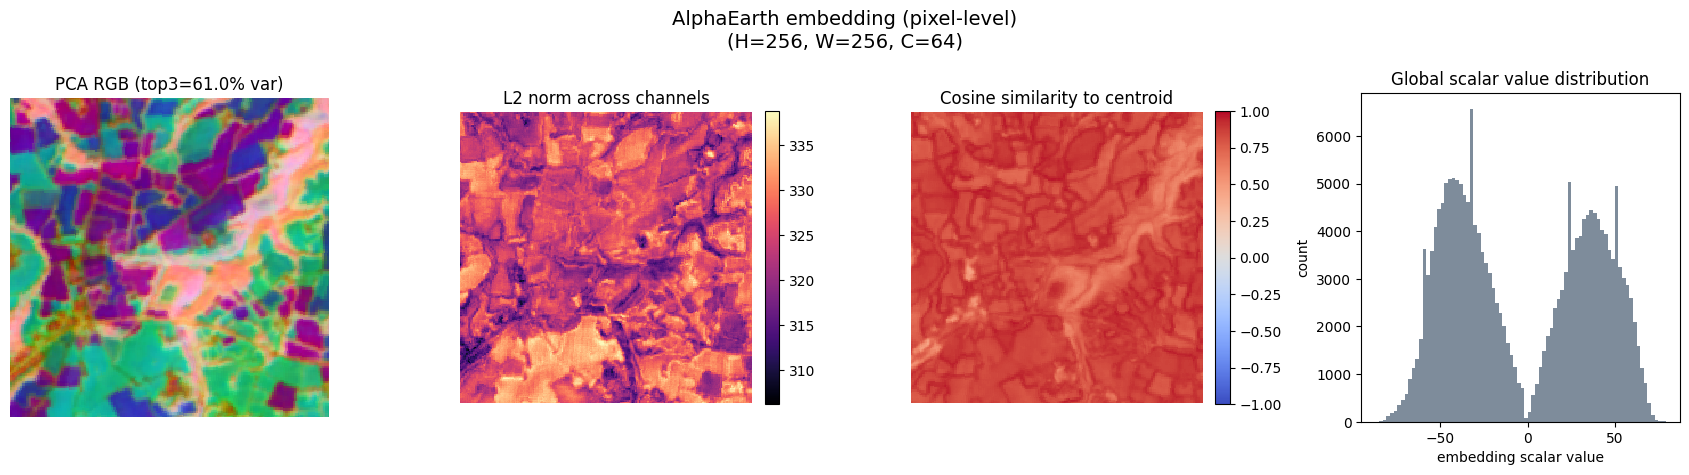


Tessera embedding (pixel-level)
  file: data\public\embed2heights\data\train\tessera_emb\tessera_emb_0000_BE.tif
  shape (H, W, C): (256, 256, 128)
  dtype: float32
  value range: [-13.1056, 14.2691] (p01=-6.1453, p99=6.3796)


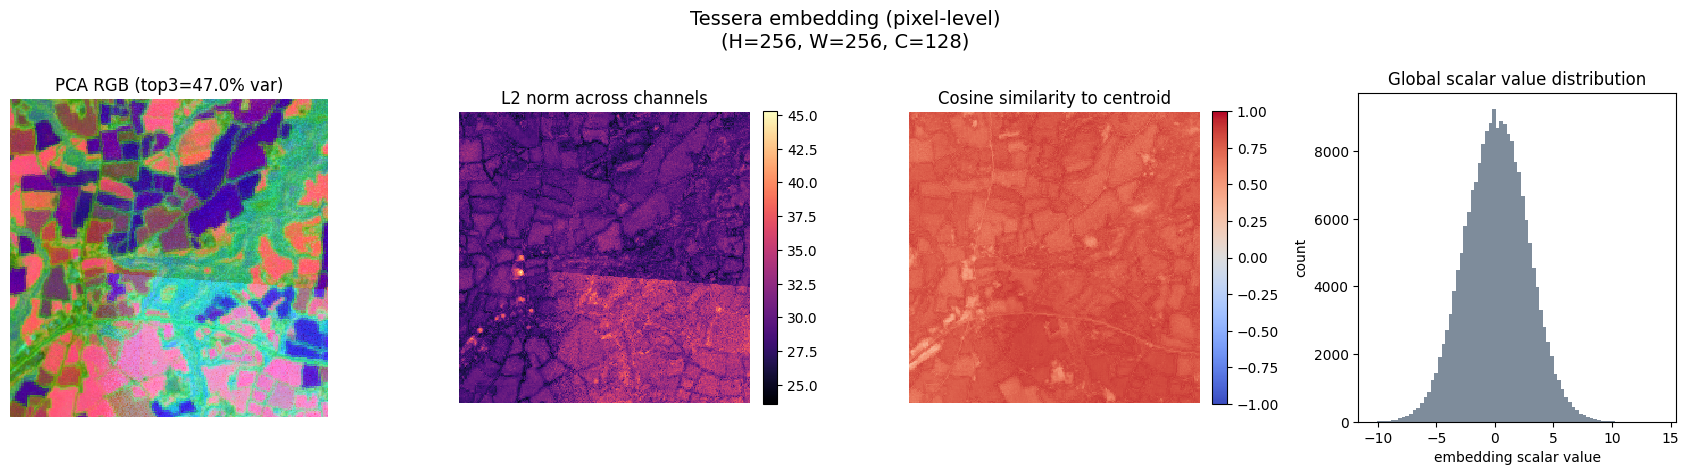


TerraMind S1 embedding (patch-level)
  file: data\public\embed2heights\data\train\terramind_s1_emb\s1_0000_BE_2023_embeddings.tif
  shape (H, W, C): (16, 16, 768)
  dtype: float32
  value range: [-11.1151, 6.2522] (p01=-1.9765, p99=1.9602)


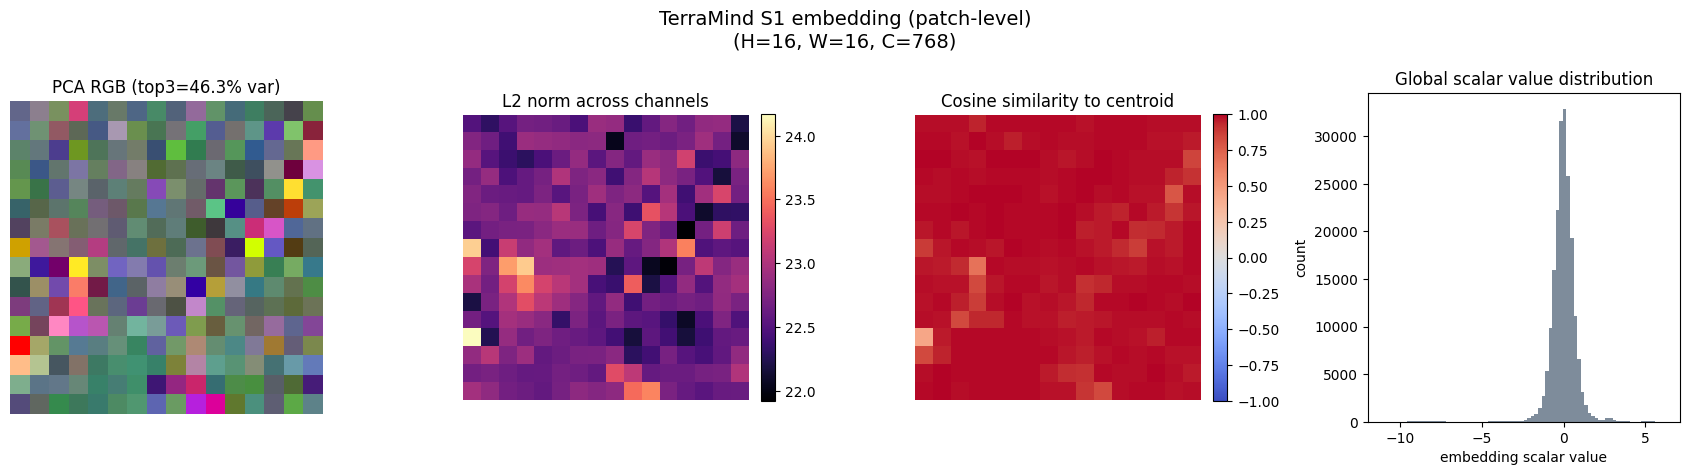


TerraMind S2 embedding (patch-level)
  file: data\public\embed2heights\data\train\terramind_s2_emb\s2_0000_BE_2023_embeddings.tif
  shape (H, W, C): (16, 16, 768)
  dtype: float32
  value range: [-11.8845, 17.5115] (p01=-1.8005, p99=2.5839)


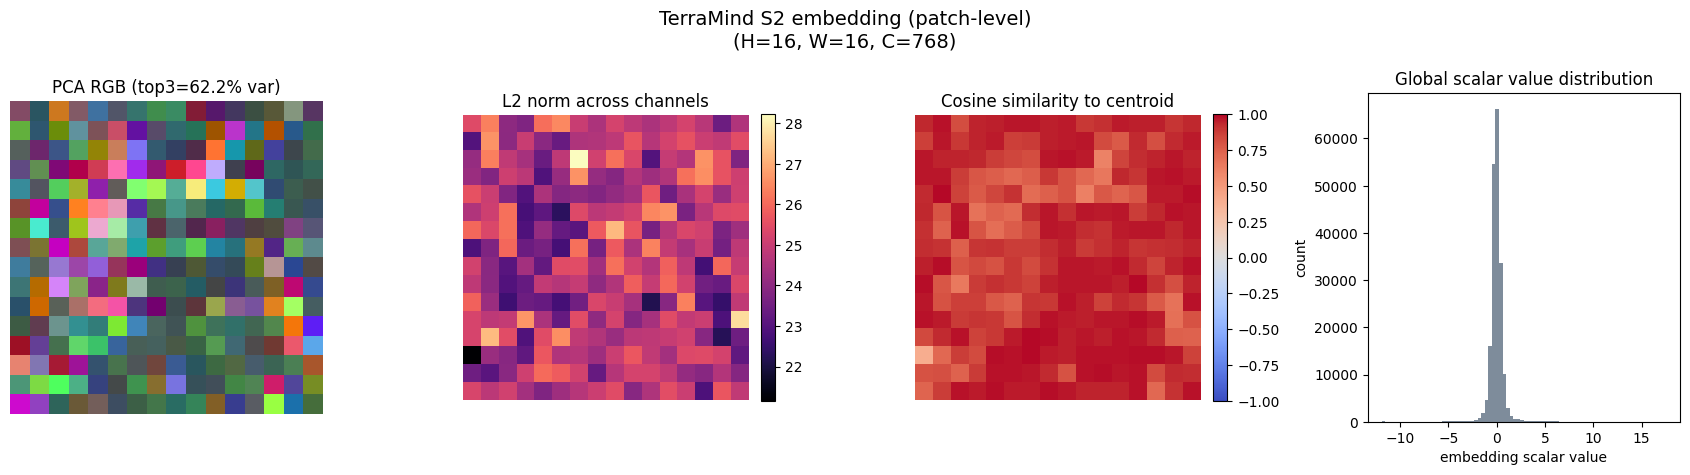


THOR S1 embedding (patch-level)
  file: data\public\embed2heights\data\train\thor_s1_emb\s1_0000_BE_2023_embedding.tif
  shape (H, W, C): (16, 16, 768)
  dtype: float32
  value range: [-126.8967, 115.5511] (p01=-43.0057, p99=49.5132)


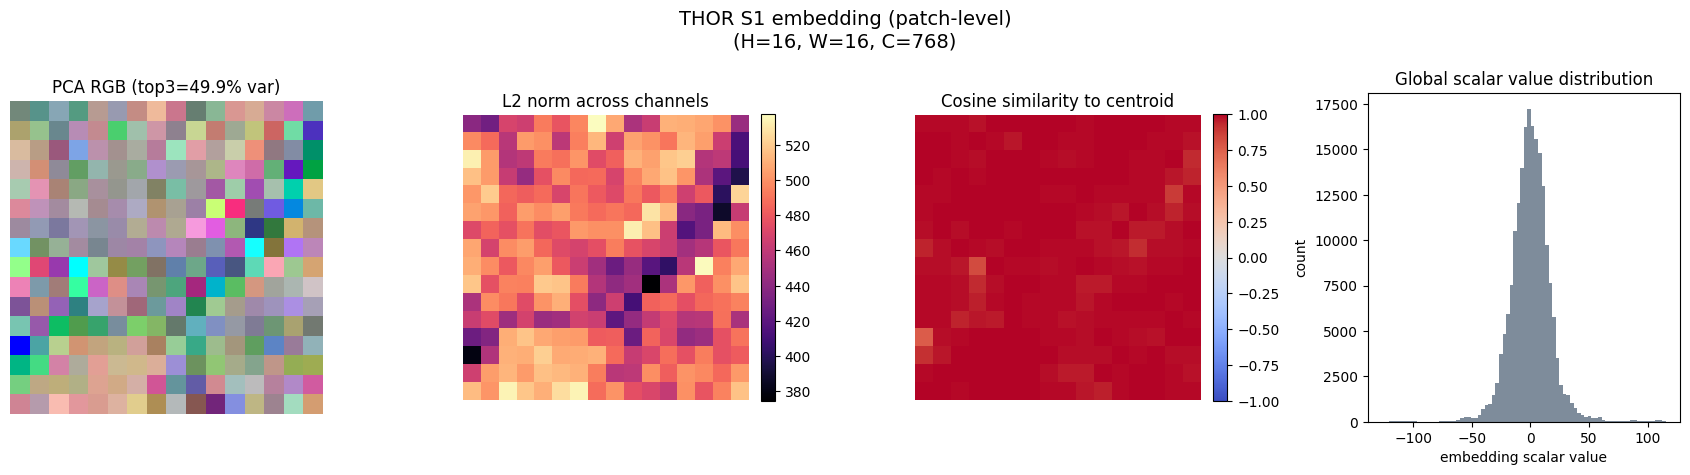


[missing] No supported files found in data\public\embed2heights\data\train\thor_s2_emb

Reference labels
  file: data\public\embed2heights\data\train\labels\label_0000_BE_2023.tif
  shape (H, W, C): (256, 256, 4)
  dtype: float32
  value range: [0.0000, 37.9177] (p01=0.0000, p99=16.1025)


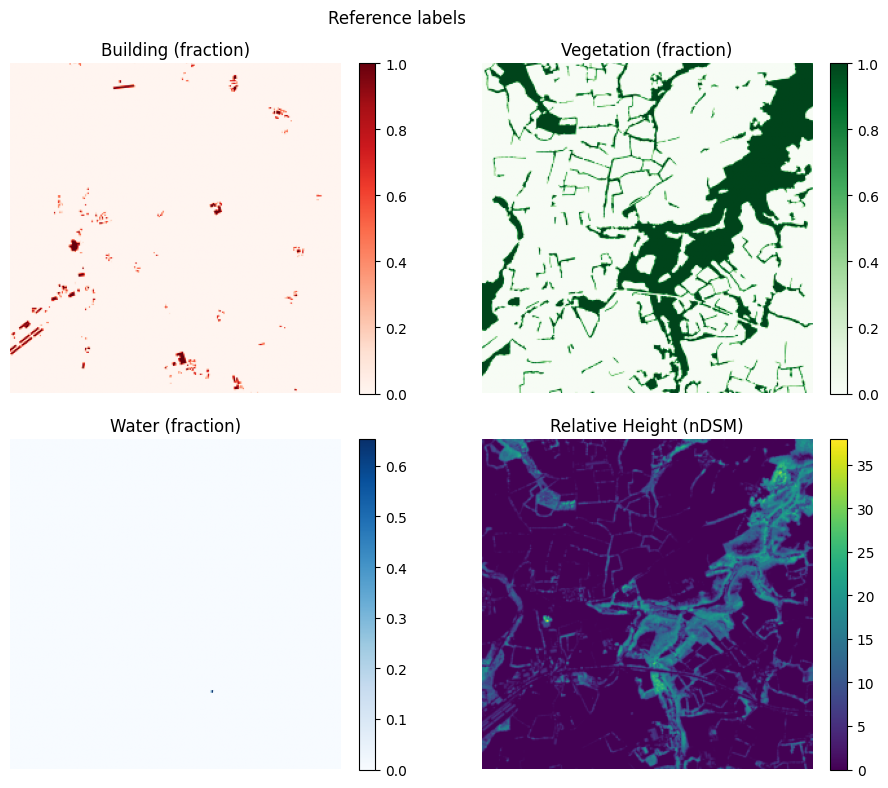

In [37]:
# One example per provided data type.
example_specs = [
    ("AlphaEarth embedding (pixel-level)", alphaearth_emb_path, "embedding"),
    ("Tessera embedding (pixel-level)", tessera_emb_path, "embedding"),
    ("TerraMind S1 embedding (patch-level)", terramind_s1_emb_path, "embedding"),
    ("TerraMind S2 embedding (patch-level)", terramind_s2_emb_path, "embedding"),
    ("THOR S1 embedding (patch-level)", thor_s1_emb_path, "embedding"),
    ("THOR S2 embedding (patch-level)", thor_s2_emb_path, "embedding"),
    ("Reference labels", labels_dir, "labels"),
]

for title, folder, kind in example_specs:
    sample_file = first_supported_file(folder)
    if sample_file is None:
        print(f"\n[missing] No supported files found in {folder}")
        continue

    arr = load_multiband_array(sample_file)
    arr_hwc = as_hwc(arr)
    print_array_summary(title, sample_file, arr_hwc)

    if kind == "labels":
        show_label_overview(arr_hwc, title)
    else:
        show_embedding_overview(arr_hwc, title)


# Baseline example

A reference baseline for this challenge is available at:

- https://github.com/VMarsocci/emb2heights-baselines

The repository currently contains an end-to-end training and inference pipeline that predicts 4 channels from EO embeddings:

- Building coverage (0-1)
- Vegetation coverage (0-1)
- Water coverage (0-1)
- Height (nDSM, meters)

Key baseline design choices:

- Model options: `lightunet`, `decoder`, `decoder_residual`, and `auto` selection.
- Composite training loss combining MAE (foreground/background split), SSIM + gradient consistency, Tversky (higher FN penalty), and a building-aware height term.
- Training stabilization with AdamW and gradient clipping.

Repository organization includes `core/model.py`, `core/dataset.py`, `core/losses.py`, a training entrypoint (`train.py`), and an inference entrypoint (`predict.py`).

Inference outputs are saved as `.npy` tensors with shape `[4, H, W]` and predictions are typically written under `runs/<experiment_name>/predictions`.

# Submission

Official submission format for this challenge:

- Upload **one single `.zip` file**.
- The zip must contain **one internal folder** (for example `predictions/`).
- Inside that folder, include all the required prediction files in **NumPy `.npy`** format.
- Each `.npy` file stores 4 bands in `[4, H, W]` order (float values):
  - `building`: per-pixel building cover score (fraction/percentage of built-up surface).
  - `vegetation`: per-pixel vegetation cover score (fraction/percentage of vegetated surface).
  - `water`: per-pixel water cover score (fraction/percentage of water surface).
  - `height`: per-pixel relative height above ground (`nDSM`), typically in meters.

Submission and leaderboard rules:

- A valid submission **must include predictions for all 946 test patches**.
- Each evaluated submission receives a **public score**, computed on a subset of test patches.
- Each evaluated submission also receives a **private score**, computed on the full test set and used for final ranking.
- At the end of the challenge, private scores are revealed and the final leaderboard is computed using the private score.

This example takes baseline inference outputs (`.npy` files from
`runs/<experiment_name>/predictions`) and packages them into a submission zip
ready to upload.


In [ ]:
from pathlib import Path
import numpy as np
import zipfile


experiment_name = "test_terramind_s1_decoder_residual"

experiment_predictions_subfolder = "predictions_renamed_correctly"

zip_name = "submission_6_without_label_prefix_with_xxxx_suffix.zip"

submission_dir = Path("submission")
submission_dir.mkdir(exist_ok=True)

submission_inner_dir = "predictions"
submission_zip_path = submission_dir / zip_name

# Baseline inference output folder (edit <experiment_name> or the full path as needed).
baseline_predictions_dir = Path("runs") / experiment_name / experiment_predictions_subfolder

if not baseline_predictions_dir.exists():
    raise FileNotFoundError(
        f"Prediction folder not found: {baseline_predictions_dir}\n"
        "Set `baseline_predictions_dir` to the folder generated by baseline inference."
    )

prediction_files = sorted(baseline_predictions_dir.glob("*.npy"))
if not prediction_files:
    raise FileNotFoundError(f"No .npy files found in: {baseline_predictions_dir}")

# Sanity check: first file must be [4, H, W].
sample = np.load(prediction_files[0])
if sample.ndim != 3 or sample.shape[0] != 4:
    raise ValueError(
        f"Invalid prediction shape {sample.shape} in {prediction_files[0].name}. "
        "Expected [4, H, W]."
    )

# Build submission zip with required internal folder structure.
with zipfile.ZipFile(submission_zip_path, "w", compression=zipfile.ZIP_DEFLATED) as zf:
    for npy_file in prediction_files:
        # zf.write(npy_file, arcname=f"{npy_file.name}")
        zf.write(npy_file, arcname=f"{submission_inner_dir}/{npy_file.name}")

print("Submission ready:")
print(f"  source folder: {baseline_predictions_dir}")
print(f"  files zipped: {len(prediction_files)}")
print(f"  sample file: {prediction_files[0].name}")
print(f"  sample shape: {sample.shape}")
print(f"  sample dtype: {sample.dtype}")
print(f"  zip file: {submission_zip_path}")


Submission ready:
  source folder: runs\test_terramind_s1_decoder_residual\predictions_renamed_with_label_and_year
  files zipped: 946
  sample file: label_3001_BE_2023.npy
  sample shape: (4, 256, 256)
  sample dtype: float32
  zip file: submission\submission_4_renamed_with_label_and_year.zip
